In [7]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

In [8]:
# Load data
bls = pd.read_csv("cw-bls.csv", index_col=0)
own = pd.read_csv("cw-own.csv", index_col=0)

C:\Users\OSCARJ\AppData\Local\Temp\ipykernel_67292\2126777322.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  own = pd.read_csv("cw-own.csv", index_col=0)


In [9]:
# Clean column names
bls.columns = [c.strip() for c in bls.columns]
own.columns = [c.strip() for c in own.columns]

# Drop unnamed first columns if present
for df in (bls, own):
    unnamed = [c for c in df.columns if c.lower().startswith('unnamed') or c == '']
    if unnamed:
        df.drop(columns=unnamed, inplace=True, errors='ignore')

# Normalize key columns
for df in (bls, own):
    if 'ISCO-08 Code' in df.columns:
        df['ISCO-08 Code'] = pd.to_numeric(df['ISCO-08 Code'], errors='coerce').astype('Int64')
    if '2010 SOC Code' in df.columns:
        df['2010 SOC Code'] = df['2010 SOC Code'].astype(str).str.strip()
    if 'Task ID' in df.columns:
        df['Task ID'] = pd.to_numeric(df['Task ID'], errors='coerce')

# Ordinal mappings
exp_map = {'E0':0, 'E1':1, 'E2':2, 'E3':3}
autocat_map = {'T0':0, 'T1':1, 'T2':2, 'T3':3}

# Convert comparable variables to numeric
for name, df in [('bls', bls), ('own', own)]:
    if 'gpt4_exposure' in df.columns:
        df['gpt4_exposure_num'] = df['gpt4_exposure'].astype(str).str.strip().map(exp_map)
    if 'human_exposure_agg' in df.columns:
        df['human_exposure_num'] = df['human_exposure_agg'].astype(str).str.strip().map(exp_map)
    if 'gpt4_exposure_alt_rubric' in df.columns:
        df['gpt4_exposure_alt_num'] = df['gpt4_exposure_alt_rubric'].astype(str).str.strip().map(exp_map)
    if 'gpt4_automation' in df.columns:
        df['gpt4_automation_num'] = df['gpt4_automation'].astype(str).str.strip().map(autocat_map)
    if 'automation' in df.columns:
        df['automation'] = pd.to_numeric(df['automation'], errors='coerce')

In [10]:
# Basic diagnostics
results = {}
results['n_rows_bls'] = len(bls)
results['n_rows_own'] = len(own)
results['n_isco_bls'] = bls['ISCO-08 Code'].nunique(dropna=True)
results['n_isco_own'] = own['ISCO-08 Code'].nunique(dropna=True)
results['n_soc_bls'] = bls['2010 SOC Code'].nunique(dropna=True)
results['n_soc_own'] = own['2010 SOC Code'].nunique(dropna=True)
results['n_tasks_bls'] = bls['Task ID'].nunique(dropna=True)
results['n_tasks_own'] = own['Task ID'].nunique(dropna=True)

# Overlap by ISCO occupation (this is the relevant comparison key)
common_isco = sorted(set(bls['ISCO-08 Code'].dropna().astype(int)).intersection(set(own['ISCO-08 Code'].dropna().astype(int))))
results['n_isco_overlap'] = len(common_isco)
results['share_isco_overlap_over_bls'] = len(common_isco) / results['n_isco_bls'] if results['n_isco_bls'] else np.nan
results['share_isco_overlap_over_own'] = len(common_isco) / results['n_isco_own'] if results['n_isco_own'] else np.nan

In [1]:
# Crosswalk structure metrics at ISCO level

def structure_metrics(df):
    g = df.groupby('ISCO-08 Code').agg(
        n_soc=('2010 SOC Code', pd.Series.nunique),
        n_tasks=('Task ID', pd.Series.nunique),
        mean_automation=('automation', 'mean'),
        mean_exp_num=('gpt4_exposure_num', 'mean'),
        mean_human_exp_num=('human_exposure_num', 'mean'),
        mean_gpt4_automation_num=('gpt4_automation_num', 'mean'),
        share_high_exp=('gpt4_exposure_num', lambda x: np.mean(pd.Series(x).dropna() >= 2) if pd.Series(x).dropna().shape[0] else np.nan),
        share_relevant=('gpt_3_relevant', lambda x: np.mean(pd.Series(x).astype(str).str.lower().isin(['true','1'])) if len(x) else np.nan)
    ).reset_index()
    return g

bls_occ = structure_metrics(bls)
own_occ = structure_metrics(own)

# Compare only common ISCO occupations
cmp = bls_occ.merge(own_occ, on='ISCO-08 Code', suffixes=('_bls', '_own'))

# Correlations across occupation-level aggregates
metrics = [
    ('mean_automation_bls', 'mean_automation_own'),
    ('mean_exp_num_bls', 'mean_exp_num_own'),
    ('mean_human_exp_num_bls', 'mean_human_exp_num_own'),
    ('mean_gpt4_automation_num_bls', 'mean_gpt4_automation_num_own'),
    ('share_high_exp_bls', 'share_high_exp_own'),
    ('n_soc_bls', 'n_soc_own'),
    ('n_tasks_bls', 'n_tasks_own')
]

corrs = {}
for a,b in metrics:
    sub = cmp[[a,b]].dropna()
    if len(sub) >= 2:
        try:
            corrs[f'pearson_{a}_vs_{b}'] = pearsonr(sub[a], sub[b])[0]
        except Exception:
            corrs[f'pearson_{a}_vs_{b}'] = np.nan
        try:
            corrs[f'spearman_{a}_vs_{b}'] = spearmanr(sub[a], sub[b]).correlation
        except Exception:
            corrs[f'spearman_{a}_vs_{b}'] = np.nan
    else:
        corrs[f'pearson_{a}_vs_{b}'] = np.nan
        corrs[f'spearman_{a}_vs_{b}'] = np.nan

# Difference summaries
for var in ['mean_automation','mean_exp_num','mean_human_exp_num','mean_gpt4_automation_num','share_high_exp','n_soc','n_tasks']:
    cmp[f'diff_{var}'] = cmp[f'{var}_own'] - cmp[f'{var}_bls']

summary_diffs = cmp[[c for c in cmp.columns if c.startswith('diff_')]].agg(['mean','median','std','min','max']).T

# Top occupation disagreements by exposure
if {'mean_exp_num_bls','mean_exp_num_own'}.issubset(cmp.columns):
    cmp['abs_diff_mean_exp_num'] = (cmp['mean_exp_num_own'] - cmp['mean_exp_num_bls']).abs()
    top_disagree = cmp.sort_values('abs_diff_mean_exp_num', ascending=False).head(15)
else:
    top_disagree = pd.DataFrame()

# Top-decile agreement / top-10 agreement if enough occupations
agreement = {}
if len(cmp) >= 10:
    k = max(1, int(np.ceil(len(cmp)*0.10)))
    top_bls = set(cmp.nlargest(k, 'mean_exp_num_bls')['ISCO-08 Code'])
    top_own = set(cmp.nlargest(k, 'mean_exp_num_own')['ISCO-08 Code'])
    agreement['top_decile_k'] = k
    agreement['top_decile_overlap_count'] = len(top_bls & top_own)
    agreement['top_decile_jaccard'] = len(top_bls & top_own) / len(top_bls | top_own) if (top_bls | top_own) else np.nan

# Print outputs in a compact, readable way
print('BASIC_COUNTS')
for k,v in results.items():
    print(f'{k}: {v}')

print('\nOCCUPATION_LEVEL_CORRELATIONS')
for k,v in corrs.items():
    print(f'{k}: {v}')

print('\nDIFF_SUMMARY')
print(summary_diffs.round(4).to_string())

print('\nTOP_DISAGREEMENTS_BY_MEAN_EXPOSURE')
cols = ['ISCO-08 Code','n_soc_bls','n_soc_own','n_tasks_bls','n_tasks_own','mean_exp_num_bls','mean_exp_num_own','abs_diff_mean_exp_num']
cols = [c for c in cols if c in top_disagree.columns]
if len(top_disagree):
    print(top_disagree[cols].round(4).to_string(index=False))
else:
    print('No disagreement table available')

print('\nTOP_DECILE_AGREEMENT')
for k,v in agreement.items():
    print(f'{k}: {v}')

# A small preview of comparable occupation table
print('\nCMP_PREVIEW')
preview_cols = ['ISCO-08 Code','n_soc_bls','n_soc_own','n_tasks_bls','n_tasks_own','mean_exp_num_bls','mean_exp_num_own','mean_automation_bls','mean_automation_own']
preview_cols = [c for c in preview_cols if c in cmp.columns]
print(cmp[preview_cols].head(10).round(4).to_string(index=False))

NameError: name 'bls' is not defined

C:\Users\OSCARJ\AppData\Local\Temp\ipykernel_73028\17035349.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  own = pd.read_csv("cw-own.csv")


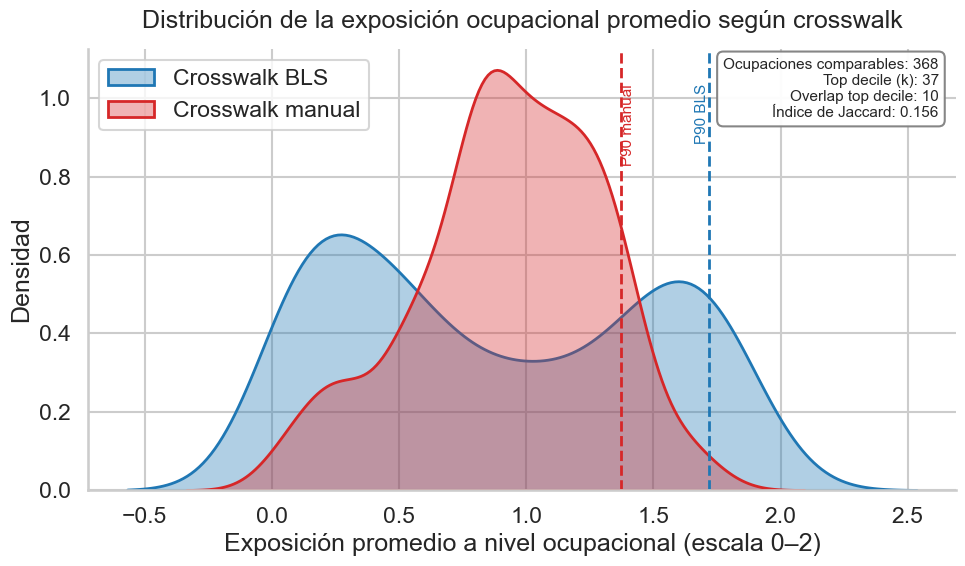

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Cargar y limpiar datos
# =========================
bls = pd.read_csv("cw-bls.csv")
own = pd.read_csv("cw-own.csv")

# Limpiar nombres de columnas
bls.columns = [c.strip() for c in bls.columns]
own.columns = [c.strip() for c in own.columns]

# Eliminar columnas índice accidentales si existen
for df in (bls, own):
    drop_cols = [c for c in df.columns if c.lower().startswith("unnamed") or c == ""]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True, errors="ignore")

# Normalizar variable ocupacional
for df in (bls, own):
    df["ISCO-08 Code"] = pd.to_numeric(df["ISCO-08 Code"], errors="coerce").astype("Int64")

# Mapear exposición ordinal a escala numérica
exp_map = {"E0": 0, "E1": 1, "E2": 2, "E3": 3}

for df in (bls, own):
    df["gpt4_exposure_num"] = (
        df["gpt4_exposure"]
        .astype(str)
        .str.strip()
        .map(exp_map)
    )

# ============================================
# 2. Agregar a nivel ocupacional (ISCO-08 Code)
# ============================================
bls_occ = (
    bls.groupby("ISCO-08 Code", as_index=False)
       .agg(mean_exp_bls=("gpt4_exposure_num", "mean"))
)

own_occ = (
    own.groupby("ISCO-08 Code", as_index=False)
       .agg(mean_exp_own=("gpt4_exposure_num", "mean"))
)

# Mantener solo ocupaciones comparables
cmp = bls_occ.merge(own_occ, on="ISCO-08 Code", how="inner").dropna()

# ========================================
# 3. Calcular percentil 90 y overlap top 10
# ========================================
p90_bls = cmp["mean_exp_bls"].quantile(0.90)
p90_own = cmp["mean_exp_own"].quantile(0.90)

k = int(np.ceil(len(cmp) * 0.10))

top_bls = set(cmp.nlargest(k, "mean_exp_bls")["ISCO-08 Code"])
top_own = set(cmp.nlargest(k, "mean_exp_own")["ISCO-08 Code"])

overlap_count = len(top_bls & top_own)
jaccard = overlap_count / len(top_bls | top_own)

# ==========================
# 4. Gráfico de distribución
# ==========================
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(10, 6))

# Distribuciones suavizadas
sns.kdeplot(
    cmp["mean_exp_bls"],
    fill=True,
    alpha=0.35,
    linewidth=2,
    color="#1f77b4",
    label="Crosswalk BLS"
)

sns.kdeplot(
    cmp["mean_exp_own"],
    fill=True,
    alpha=0.35,
    linewidth=2,
    color="#d62728",
    label="Crosswalk manual"
)

# Líneas del percentil 90
ax.axvline(p90_bls, color="#1f77b4", linestyle="--", linewidth=2)
ax.axvline(p90_own, color="#d62728", linestyle="--", linewidth=2)

# Etiquetas del percentil 90
ax.text(
    p90_bls,
    ax.get_ylim()[1] * 0.92,
    "P90 BLS",
    color="#1f77b4",
    rotation=90,
    va="top",
    ha="right",
    fontsize=11
)

ax.text(
    p90_own,
    ax.get_ylim()[1] * 0.92,
    "P90 manual",
    color="#d62728",
    rotation=90,
    va="top",
    ha="left",
    fontsize=11
)

# Caja de texto con overlap del top decile
textstr = (
    f"Ocupaciones comparables: {len(cmp)}\n"
    f"Top decile (k): {k}\n"
    f"Overlap top decile: {overlap_count}\n"
    f"Índice de Jaccard: {jaccard:.3f}"
)

ax.text(
    0.98, 0.98, textstr,
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.95)
)

# Formato
ax.set_title("Distribución de la exposición ocupacional promedio según crosswalk", pad=15)
ax.set_xlabel("Exposición promedio a nivel ocupacional (escala 0–2)")
ax.set_ylabel("Densidad")
ax.legend(frameon=True)
sns.despine()

plt.tight_layout()
plt.show()

C:\Users\OSCARJ\AppData\Local\Temp\ipykernel_73028\1069644086.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  own = pd.read_csv("cw-own.csv")


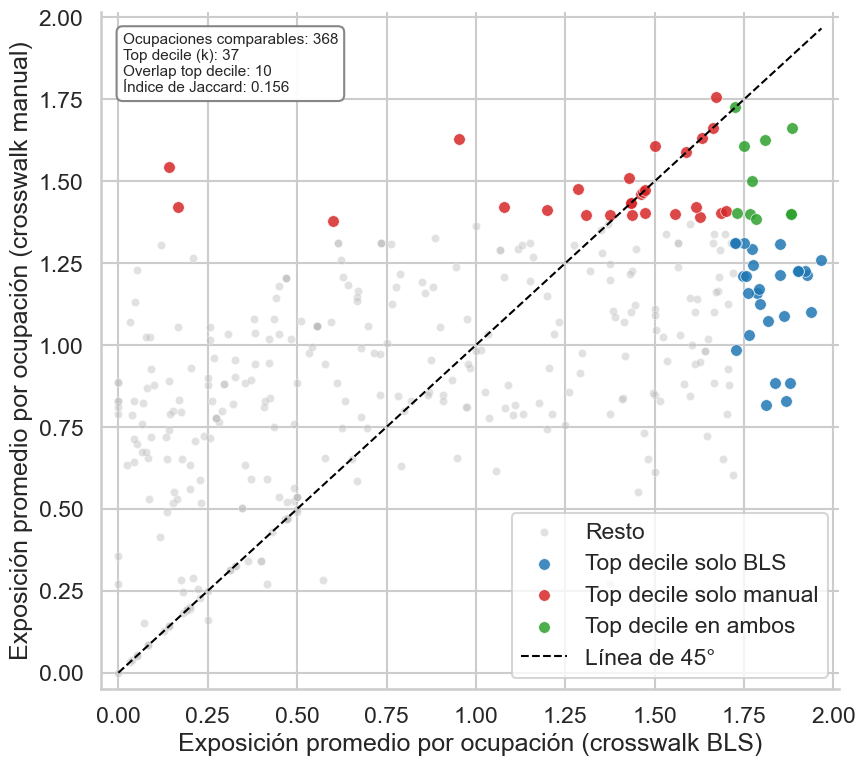

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Cargar y limpiar datos
# =========================
bls = pd.read_csv("cw-bls.csv")
own = pd.read_csv("cw-own.csv")

bls.columns = [c.strip() for c in bls.columns]
own.columns = [c.strip() for c in own.columns]

for df in (bls, own):
    drop_cols = [c for c in df.columns if c.lower().startswith("unnamed") or c == ""]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True, errors="ignore")

    df["ISCO-08 Code"] = pd.to_numeric(df["ISCO-08 Code"], errors="coerce").astype("Int64")

# Mapear exposición ordinal a escala numérica
exp_map = {"E0": 0, "E1": 1, "E2": 2, "E3": 3}

for df in (bls, own):
    df["gpt4_exposure_num"] = (
        df["gpt4_exposure"]
        .astype(str)
        .str.strip()
        .map(exp_map)
    )

# ============================================
# 2. Agregar a nivel ocupacional (ISCO-08 Code)
# ============================================
bls_occ = (
    bls.groupby("ISCO-08 Code", as_index=False)
       .agg(mean_exp_bls=("gpt4_exposure_num", "mean"))
)

own_occ = (
    own.groupby("ISCO-08 Code", as_index=False)
       .agg(mean_exp_own=("gpt4_exposure_num", "mean"))
)

cmp = bls_occ.merge(own_occ, on="ISCO-08 Code", how="inner").dropna()

# ========================================
# 3. Identificar top decile en cada ranking
# ========================================
k = int(np.ceil(len(cmp) * 0.10))

top_bls = set(cmp.nlargest(k, "mean_exp_bls")["ISCO-08 Code"])
top_own = set(cmp.nlargest(k, "mean_exp_own")["ISCO-08 Code"])

def classify_top(isco):
    in_bls = isco in top_bls
    in_own = isco in top_own
    if in_bls and in_own:
        return "Top decile en ambos"
    elif in_bls:
        return "Top decile solo BLS"
    elif in_own:
        return "Top decile solo manual"
    else:
        return "Resto"

cmp["grupo_top"] = cmp["ISCO-08 Code"].apply(classify_top)

# Jaccard
overlap_count = len(top_bls & top_own)
jaccard = overlap_count / len(top_bls | top_own)

# =================
# 4. Scatter plot
# =================
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "Resto": "#bdbdbd",
    "Top decile solo BLS": "#1f77b4",
    "Top decile solo manual": "#d62728",
    "Top decile en ambos": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(9, 8))

# Graficar por grupo para controlar colores y orden visual
for group in ["Resto", "Top decile solo BLS", "Top decile solo manual", "Top decile en ambos"]:
    sub = cmp[cmp["grupo_top"] == group]
    ax.scatter(
        sub["mean_exp_bls"],
        sub["mean_exp_own"],
        s=70 if group != "Resto" else 35,
        alpha=0.85 if group != "Resto" else 0.45,
        color=palette[group],
        edgecolor="white",
        linewidth=0.5,
        label=group
    )

# Línea de 45 grados
xmin = min(cmp["mean_exp_bls"].min(), cmp["mean_exp_own"].min())
xmax = max(cmp["mean_exp_bls"].max(), cmp["mean_exp_own"].max())

ax.plot(
    [xmin, xmax],
    [xmin, xmax],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Línea de 45°"
)

# Límites
ax.set_xlim(xmin - 0.05, xmax + 0.05)
ax.set_ylim(xmin - 0.05, xmax + 0.05)

# Etiquetas
#ax.set_title("Comparación de exposición ocupacional promedio entre crosswalks", pad=15)
ax.set_xlabel("Exposición promedio por ocupación (crosswalk BLS)")
ax.set_ylabel("Exposición promedio por ocupación (crosswalk manual)")

# Caja de texto con estadísticos
textstr = (
    f"Ocupaciones comparables: {len(cmp)}\n"
    f"Top decile (k): {k}\n"
    f"Overlap top decile: {overlap_count}\n"
    f"Índice de Jaccard: {jaccard:.3f}"
)

ax.text(
    0.03, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.95)
)

ax.legend(frameon=True, loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()